# Analysis of the Macbeth Fandom

AI Usage Acknowledgement: the visualization code in this notebook is created by Claude Code. The idea of analysis and text analysis is written by human and polished by the same AI.

In [1]:
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", None)
DB = "macbeth.db" # Database file, put in the same directory

BLUE, LIGHT_BLUE, INK, MUTED, GRID, SURFACE = "#2a78d6", "#9ec5f4", "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110, "font.size": 10,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": INK,
    "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 11,
})

db = sqlite3.connect(DB)
works = pd.read_sql("SELECT * FROM works", db, parse_dates=["published", "updated"])
tags = pd.read_sql("SELECT * FROM tags", db)
comments = pd.read_sql("SELECT * FROM comments", db, parse_dates=["posted"])
snapshot = works.fetched_at.max()[:10]


def bars(values, title, ax=None, unit=""):
    """Horizontal bars in the order given, each labelled with its value."""
    if ax is None:
        ax = plt.subplots(figsize=(7, 0.34 * len(values) + 0.9))[1]
    values = values.iloc[::-1]
    ax.barh(values.index.astype(str), values, height=0.62, color=BLUE)
    for y, value in enumerate(values):
        ax.text(value, y, f" {value:,.0f}{unit}", va="center")
    ax.set_title(title)
    ax.set_xlim(0, values.max() * 1.15)
    ax.set_xticks([])
    ax.grid(False)
    ax.spines[["left", "bottom"]].set_visible(False)
    ax.tick_params(length=0)


def tag_counts(tag_type):
    return tags[tags.type == tag_type].tag.value_counts()

## 1. General Statistics

In [2]:
authors = works.authors[works.authors != ""].str.split("; ").explode()
pd.Series({
    "Works": f"{len(works):,}",
    "Distinct authors": f"{authors.nunique():,}",
    "Anonymous works": f"{(works.authors == '').sum():,}",
    "Chapters": f"{pd.read_sql('SELECT COUNT(*) FROM chapters', db).iloc[0, 0]:,}",
    "Words (AO3's count)": f"{works.words.sum() / 1e6:.2f} million",
    "Comments collected": f"{len(comments):,}",
    "Distinct commenters with an account": f"{comments[comments.guest == 0].author.nunique():,}",
    "First work published": str(works.published.min().date()),
    "Pages fetched up to": snapshot,
    "Languages": ", ".join(f"{name} ({n})" for name, n in works.language.value_counts().items()),
}).to_frame(DB)

,macbeth.db
Works,593
Distinct authors,469
Anonymous works,17
Chapters,"1,739"
Words (AO3's count),3.06 million
Comments collected,"3,847"
Distinct commenters with an account,"1,290"
First work published,2010-10-24
Pages fetched up to,2026-10-09
Languages,"English (579), Русский (7), 中文-普通话 國語 (4), Italiano (1), Polski (1), Español (1)"


In [3]:
works_per_author = authors.value_counts()
print(f"{(works_per_author == 1).sum()} of {len(works_per_author)} authors have exactly one work in this fandom.")
print(f"{works.authors.str.contains('; ').sum()} works are co-authored.")
print(f"{(authors == 'orphan_account').sum()} works sit under orphan_account, which counts as one of the {len(works_per_author)} authors.")
print(f"Comments collected: {len(comments):,} of the {works.comments.sum():,} that AO3 counts ({len(comments) / works.comments.sum():.0%}).")

414 of 469 authors have exactly one work in this fandom.
19 works are co-authored.
34 works sit under orphan_account, which counts as one of the 469 authors.
Comments collected: 3,847 of the 3,927 that AO3 counts (98%).


This fandom is non-trivial but not huge as well, containing 593 works from 469 distinct authors. 414 of the 469 authors have exactly one work in the fandom; 19 works are co-authored. 17 of them are anonymous works with empty `authors` field. We collect all comments but leave out collapsed threads with nesting comments (that gives a 98% coverage already). The first work was in 2010, and this fandom is still active as of now. English is the prevalent language used, followed by some Russian and Chinese.

Note: we find that one of the 469 is "orphan_account" (we will cover it in section 4), which means the author cuts the connection with this work. Therefore, 469 is an underestimation of the real number of authors.

## 2. Growth

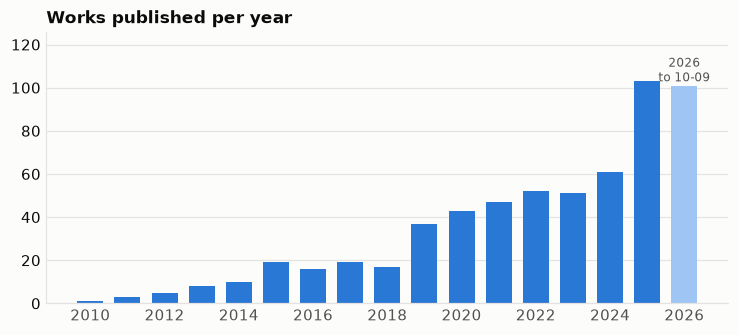

In [4]:
per_year = works.published.dt.year.value_counts().sort_index()
last_year = per_year.index.max()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(per_year.index, per_year, width=0.7, color=[LIGHT_BLUE if year == last_year else BLUE for year in per_year.index])
ax.text(last_year, per_year[last_year], f"{last_year}\nto {snapshot[5:]}", ha="center", va="bottom", color=MUTED, fontsize=8)
ax.set_title("Works published per year")
ax.set_xticks(per_year.index[::2])
ax.set_ylim(0, per_year.max() * 1.22)
ax.grid(axis="x", visible=False)
ax.tick_params(length=0)

In [5]:
print(f"Published since 2019: {per_year.loc[2019:].sum() / len(works):.0%}. Published in {last_year - 1}-{last_year}: {per_year.loc[last_year - 1:].sum() / len(works):.0%}.")
per_year.to_frame("works").T

Published since 2019: 83%. Published in 2025-2026: 34%.


published,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
works,1,3,5,8,10,19,16,19,17,37,43,47,52,51,61,103,101


The year is the date the work was first published. Works deleted since then are not counted.

83% of works were published since 2019, and 34% in 2025–2026 alone.
Output roughly doubled between 2018 (17) and 2019 (37), then again between 2024 (61) and 2025 (103).
2026 had 101 works by 9 October, so it will pass 2025 again. This comes surprising that more people are getting interested in Macbeth in the 2020s.

## 3. What is written

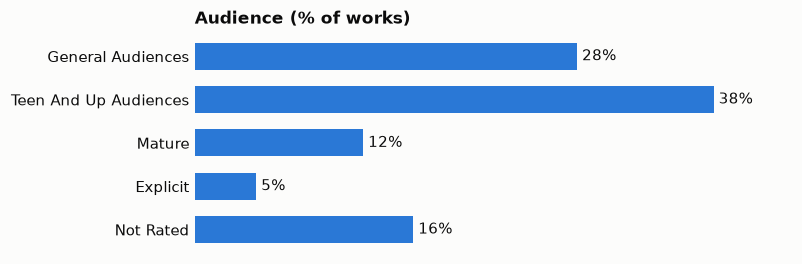

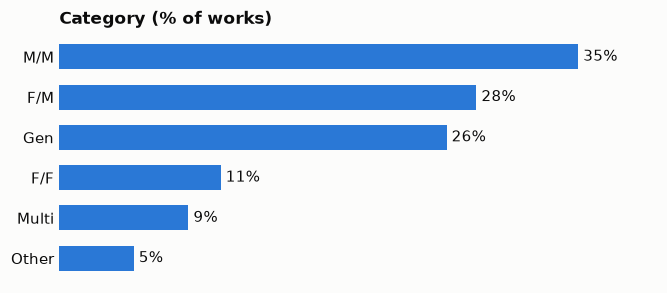

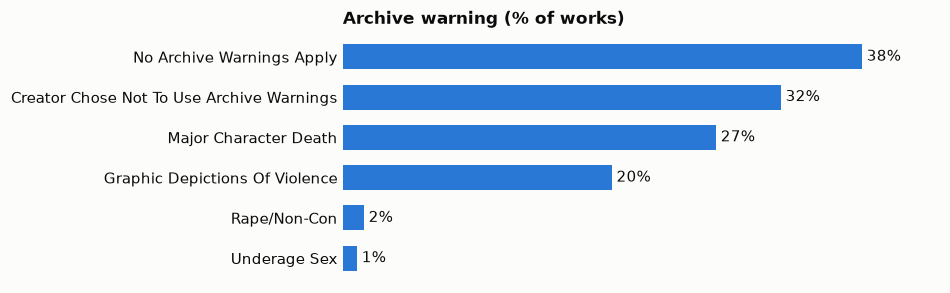

In [6]:
rating_order = ["General Audiences", "Teen And Up Audiences", "Mature", "Explicit", "Not Rated"]
share = lambda counts: counts / len(works) * 100

bars(share(works.rating.value_counts().reindex(rating_order)), "Audience (% of works)", unit="%")
bars(share(tag_counts("category")), "Category (% of works)", unit="%")
bars(share(tag_counts("warning")), "Archive warning (% of works)", unit="%")

In [7]:
print(f"{len(works) - tags[tags.type == 'category'].work_id.nunique()} works have no category.")

83 works have no category.


A work has one rating but can have several categories and warnings, so those two charts add up to more than 100%.

**What people write**
- Ratings: Teen 38%, General 28%, Not Rated 16%, Mature 12%, Explicit 5%.
- Categories: M/M 35%, F/M 28%, Gen 26%, F/F 11%, Multi 9%, Other 5%; 83 works have no category at all.
- Warnings: 27% carry Major Character Death and 20% Graphic Violence, fitting the source play; 32% chose not to use warnings.

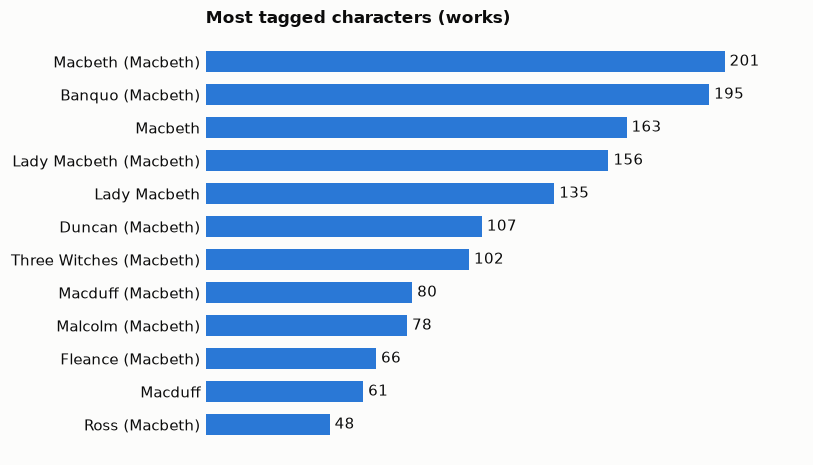

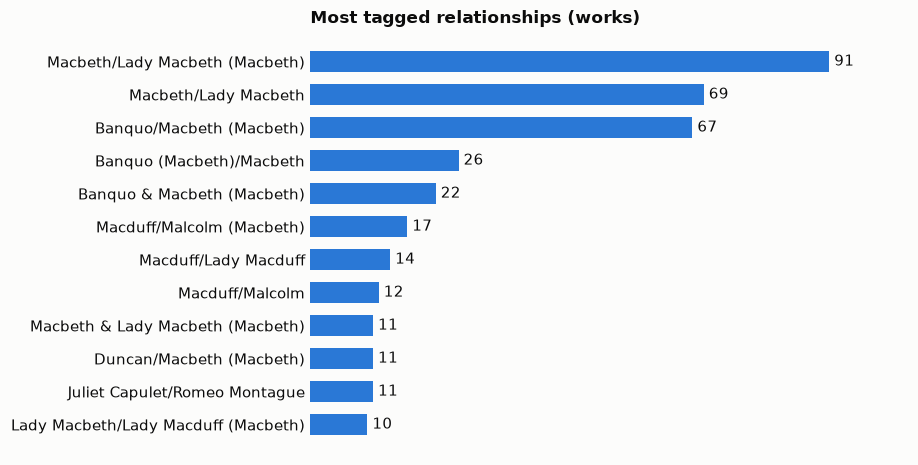

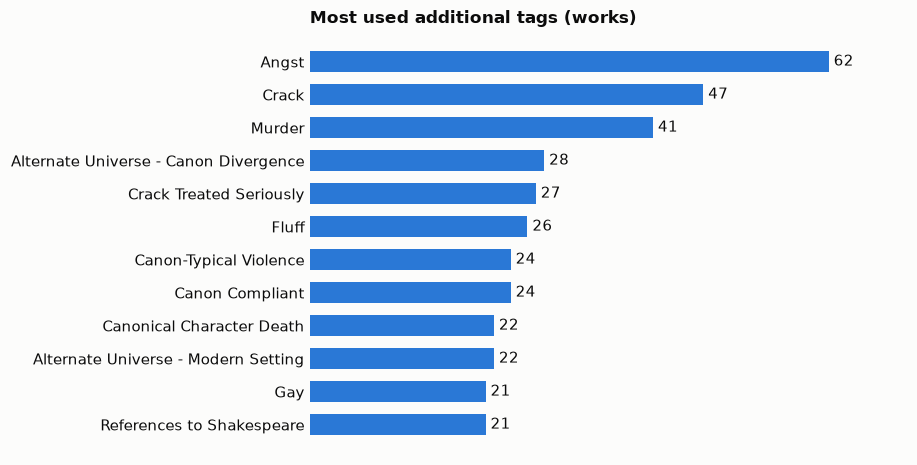

In [8]:
bars(tag_counts("character").head(12), "Most tagged characters (works)")
bars(tag_counts("relationship").head(12), "Most tagged relationships (works)")
bars(tag_counts("freeform").head(12), "Most used additional tags (works)")

In [9]:
additional = tag_counts("freeform")
fandoms_on_work = tags[tags.type == "fandom"].groupby("work_id").size()
print(f"{len(additional):,} distinct additional tags; {(additional == 1).mean():.0%} of them are used on only one work.")
print(f"Median number of tags on a work, all six types together: {tags.groupby('work_id').size().median():.0f}.")
print(f"{len(tag_counts('fandom'))} distinct fandoms appear; the most on a single work is {fandoms_on_work.max()}.")

3,209 distinct additional tags; 84% of them are used on only one work.
Median number of tags on a work, all six types together: 16.
455 distinct fandoms appear; the most on a single work is 53.


**Tags** are stored exactly as authors wrote them. The same character or pairing therefore appears under several spellings, for example with and without the "(Macbeth)" suffix, and the counts above are not merged.

- Characters: Macbeth, Banquo and Lady Macbeth dominate. Banquo is tagged about as often as Macbeth under the “(Macbeth)” spelling (195 against 201).
- One tag can has many variants: “Macbeth (Macbeth)” 201 and “Macbeth” 163; “Macbeth/Lady Macbeth (Macbeth)” 91 and “Macbeth/Lady Macbeth” 69.
- There are 3,209 distinct tags (free-form ones added by the authors), 84% of which are used only once (the long tail). The median work has 16 tags in total.
- Crossovers: 44% of works have more than one fandom, across 455 distinct fandoms; one work is tagged with 53.

44% of works are tagged with more than one fandom.


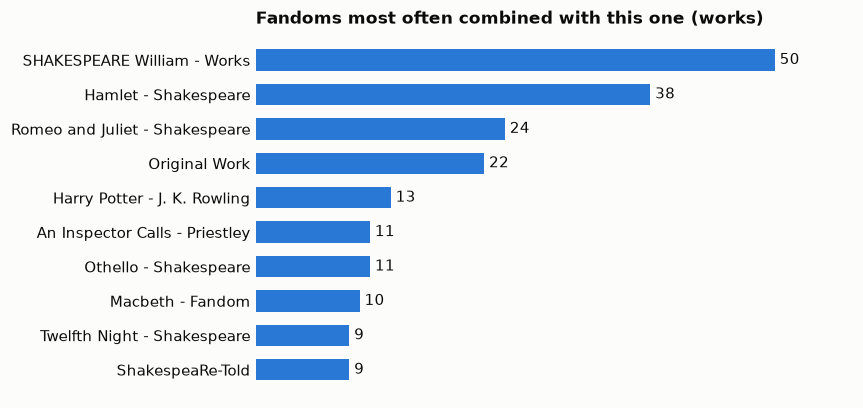

In [10]:
fandoms_per_work = tags[tags.type == "fandom"].groupby("work_id").size()
print(f"{(fandoms_per_work > 1).mean():.0%} of works are tagged with more than one fandom.")
bars(tag_counts("fandom").iloc[1:11], "Fandoms most often combined with this one (works)")

44% of works are tagged with more than one fandom. I am interested in how to combine Macbeth and HP...

## 4. Length and reception

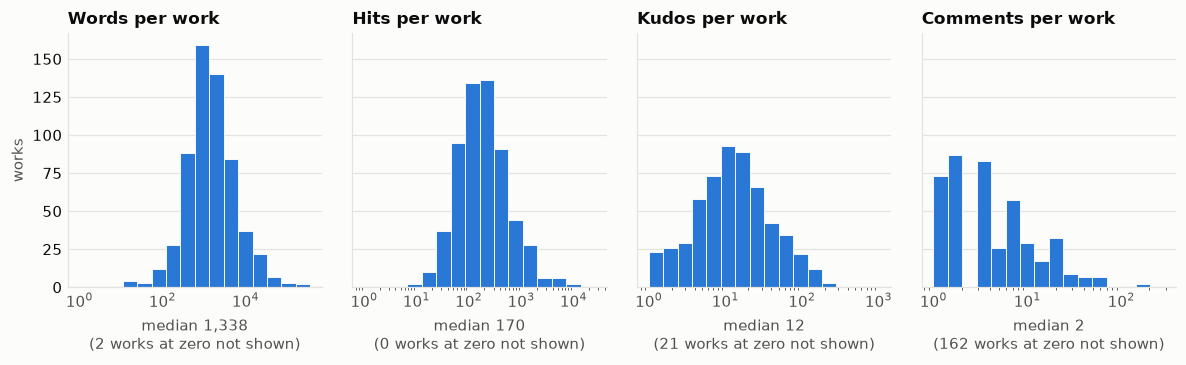

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True, gridspec_kw={"wspace": 0.12})
axes[0].set_ylabel("works")
for ax, column in zip(axes, ["words", "hits", "kudos", "comments"]):
    values = works[column].dropna()
    positive = values[values > 0]
    ax.hist(positive, bins=np.logspace(0, np.log10(positive.max()), 17), color=BLUE, edgecolor=SURFACE, linewidth=0.6)
    ax.set_xscale("log")
    ax.set_title(f"{column.capitalize()} per work")
    ax.set_xlabel(f"median {values.median():,.0f}\n({(values == 0).sum()} works at zero not shown)")
    ax.grid(axis="x", visible=False)
    ax.tick_params(length=0)

In [12]:
total_words = works.words.sum()
print(f"Words per work: median {works.words.median():,.0f}, mean {works.words.mean():,.0f}; {(works.words < 1000).mean():.0%} of works are under 1,000 words.")
print(f"The longest work has {works.words.max():,.0f} words, {works.words.max() / total_words:.0%} of all words; the ten longest hold {works.words.nlargest(10).sum() / total_words:.0%}.")
print(f"{(works.updated == works.published).mean():.0%} of works were never updated after the day they were published.")

Words per work: median 1,338, mean 5,164; 37% of works are under 1,000 words.
The longest work has 366,191 words, 12% of all words; the ten longest hold 41%.
79% of works were never updated after the day they were published.


All four are **heavily skewed**, which is why the horizontal axes are logarithmic: most works are short and lightly read, and a few are very long or very popular. In log-scale it somehow looks like a Gaussian distribution.

Kudos and comments are whole numbers, so the left ends of those two panels look gappy (because there is no "a fraction of a kudos").

**Short works dominate**: median 1,338 words, mean 5,164; 37% are under 1,000 words.
A few works hold much of the text: the longest has 366,191 words, 12% of the total; the top ten hold 41%. 79% were never updated after the day they were published.

Median kudos per hit: 6.4%


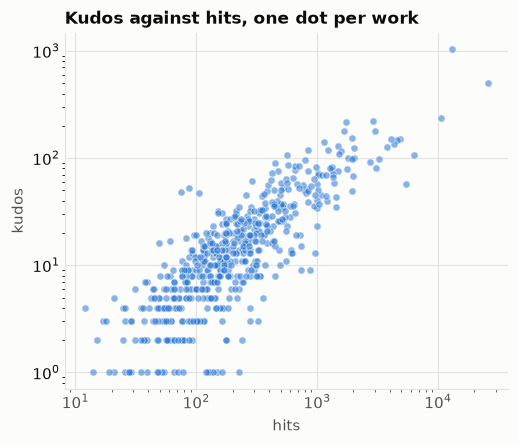

In [13]:
seen = works[(works.hits > 0) & (works.kudos > 0)]
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.scatter(seen.hits, seen.kudos, s=22, color=BLUE, alpha=0.55, edgecolor=SURFACE, linewidth=0.6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Kudos against hits, one dot per work")
ax.set_xlabel("hits")
ax.set_ylabel("kudos")
ax.tick_params(length=0)
print(f"Median kudos per hit: {(works.kudos / works.hits).median():.1%}")

In [14]:
print(f"Correlation between log hits and log kudos: {np.corrcoef(np.log1p(works.hits), np.log1p(works.kudos))[0, 1]:.2f}")
works.groupby("rating")[["kudos", "hits"]].median().reindex(rating_order)

Correlation between log hits and log kudos: 0.84


,kudos,hits
rating,,
General Audiences,12.0,164.5
Teen And Up Audiences,11.5,161.0
Mature,13.5,234.0
Explicit,36.0,627.0
Not Rated,8.5,117.5


**Kudos track hits** closely: correlation 0.84 on log scales, with a median of 6.4 kudos per 100 hits. **Explicit works get more of both**: median 36 kudos and 627 hits, against 12 and 164.5 for General.

77% of works are marked complete; 63% have a single chapter.


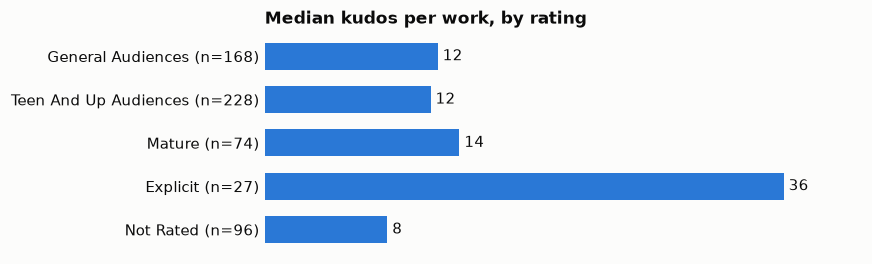

In [15]:
by_rating = works.groupby("rating").kudos.agg(["median", "size"]).reindex(rating_order)
by_rating.index = [f"{rating} (n={n})" for rating, n in zip(by_rating.index, by_rating["size"])]
bars(by_rating["median"], "Median kudos per work, by rating")

parts = works.chapters.str.split("/", expand=True)
print(f"{(parts[0] == parts[1]).mean():.0%} of works are marked complete; {(works.chapters == '1/1').mean():.0%} have a single chapter.")

In [16]:
top = works.loc[works.kudos.idxmax()]
print(f"The most-kudosed work has {top.kudos:,} kudos. Under orphan_account: {top.authors == 'orphan_account'}.")

The most-kudosed work has 1,041 kudos. Under orphan_account: True.


The most-kudosed work (1,041) sits under orphan_account.

*Orphan account*: I looked up what that is. It is a special account run by AO3 itself, not a person. It holds works whose authors have “orphaned” them.

Orphaning is an AO3 feature for authors who want to cut their connection to a work without deleting it. The work stays online for readers, but the author’s name is removed and the work is transferred to orphan_account. As far as I know it is permanent: the author can no longer edit, delete or reclaim the work.

## 5. Comments

In [17]:
thread = comments.merge(works[["work_id", "authors", "published"]], on="work_id")
thread["by_author"] = [name in names.split("; ") for name, names in zip(thread.author, thread.authors)]
reader_openers = thread[thread.parent_id.isna() & ~thread.by_author]
answered_by_author = set(thread[thread.by_author & thread.parent_id.notna()].parent_id)

pd.Series({
    "Works with at least one comment": f"{(works.comments > 0).mean():.0%}",
    "Comments that are replies to another comment": f"{comments.parent_id.notna().mean():.0%}",
    "Comments written by the work's own author": f"{thread.by_author.mean():.0%}",
    "Comments from guests (no account)": f"{comments.guest.mean():.0%}",
    "Readers' top-level comments that the author answered": f"{reader_openers.comment_id.isin(answered_by_author).mean():.0%}",
}).to_frame("share")

,share
Works with at least one comment,73%
Comments that are replies to another comment,43%
Comments written by the work's own author,34%
Comments from guests (no account),11%
Readers' top-level comments that the author answered,50%


In [18]:
per_work = comments.groupby("work_id").size()
per_account = comments[comments.guest == 0].author.value_counts()
print(f"Among works with comments: median {per_work.median():.0f} collected comments, largest {per_work.max()}.")
print(f"The ten most-commented works hold {per_work.nlargest(10).sum() / len(comments):.0%} of all comments.")
print(f"{len(per_account):,} accounts commented; {(per_account == 1).mean():.0%} of them only once.")

Among works with comments: median 4 collected comments, largest 225.
The ten most-commented works hold 28% of all comments.
1,290 accounts commented; 66% of them only once.


Among comments:
- 73% of works have at least one comment; among those, the median is 4 and the largest work has 225.
- Comments are concentrated: the ten most-commented works hold 28% of them.
- 43% of comments are replies; 34% are written by the work’s own author. Authors answered 50% of readers’ top-level comments. This shows good engagement.
- 11% of comments come from guests; 1,290 distinct accounts commented, and 66% of them did so once.

Within 1 week: 25%
Within 1 month: 40%
Within 1 year: 69%


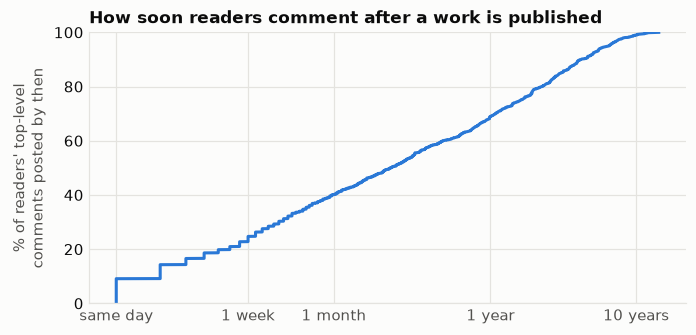

In [19]:
days = (reader_openers.posted - reader_openers.published).dt.days.clip(lower=0).sort_values()
cumulative = np.arange(1, len(days) + 1) / len(days) * 100
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(days + 1, cumulative, color=BLUE, linewidth=2)
ax.set_xscale("log")
ax.set_xticks([1, 8, 31, 366, 3651], ["same day", "1 week", "1 month", "1 year", "10 years"])
ax.minorticks_off()
ax.set_ylim(0, 100)
ax.set_title("How soon readers comment after a work is published")
ax.set_ylabel("% of readers' top-level\ncomments posted by then")
ax.tick_params(length=0)
for label, limit in [("1 week", 7), ("1 month", 30), ("1 year", 365)]:
    print(f"Within {label}: {(days <= limit).mean():.0%}")

In [20]:
print(f"Posted on publication day: {(days == 0).mean():.0%}. Median wait: {days.median():.0f} days.")
print(f"Median comment length: {comments.text.str.len().median():.0f} characters.")
comments.posted.dt.year.value_counts().sort_index().to_frame("comments posted").T

Posted on publication day: 9%. Median wait: 75 days.
Median comment length: 84 characters.


posted,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
comments posted,12,20,43,18,68,119,81,183,294,332,252,275,334,442,709,665


Among comments:
- Timing: 9% of readers’ top-level comments arrive on publication day, 25% within a week, 40% within a month, 69% within a year; the median is 75 days. Time is measured from the work's *first publication date*, so for multi-chapter works a late comment may simply follow a late chapter.
- Comments are short, with a median of merely 84 characters.
- Commenting is growing with the fandom: 709 comments were posted in 2025 and 665 so far in 2026.